In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt

def load_eeg_realizations(
    filepath,
    channel=16,
    segment_length=2000,
    start=None,
    end=None,
):
    raw = mne.io.read_raw_edf(filepath, preload=True, verbose=False)

    data = raw.get_data()
    x = data[channel]

    # optional cropping
    if start is not None and end is not None:
        x = x[int(start):int(end)]

    # preprocessing
    x = x - np.mean(x)
    x = x / np.std(x)

    # split into segments
    realizations = [
        x[i:i+segment_length]
        for i in range(0, len(x)-segment_length, segment_length)
    ]

    return realizations

eeg_data = {
    "non_seizure": [],
    "seizure": []
}

In [2]:
fs = 256  # sampling rate

# =========================
# NON-SEIZURE DATA
# =========================

eeg_data["non_seizure"] += load_eeg_realizations(
    "chb01_01.edf",
    channel=16,
    segment_length=2000,
)

eeg_data["non_seizure"] += load_eeg_realizations(
    "chb01_05.edf",
    channel=16,
    segment_length=2000,
)

# =========================
# SEIZURE DATA (CROPPED)
# =========================

# chb01_03: 2996–3036 s
eeg_data["seizure"] += load_eeg_realizations(
    "chb01_03.edf",
    channel=16,
    segment_length=2000,
    start=2996 * fs,
    end=3036 * fs,
)

# chb01_04: 1467–1494 s
eeg_data["seizure"] += load_eeg_realizations(
    "chb01_04.edf",
    channel=16,
    segment_length=2000,
    start=1467 * fs,
    end=1494 * fs,
)

# chb01_15: 1732–1772 s
eeg_data["seizure"] += load_eeg_realizations(
    "chb01_15.edf",
    channel=16,
    segment_length=2000,
    start=1732 * fs,
    end=1772 * fs,
)

/var/folders/wl/p5kp7cqd6pj_374ks21zhmw40000gn/T/ipykernel_70676/2404625708.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(filepath, preload=True, verbose=False)
/var/folders/wl/p5kp7cqd6pj_374ks21zhmw40000gn/T/ipykernel_70676/2404625708.py:12: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(filepath, preload=True, verbose=False)
/var/folders/wl/p5kp7cqd6pj_374ks21zhmw40000gn/T/ipykernel_70676/2404625708.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(filepath, preload=True, verbose=False)
/var/folders/wl/p5kp7cqd6pj_374ks21zhmw40000gn/T/ipykernel_70676/2404625708.py:12: RuntimeWarning: Number of records from the header does not mat

In [3]:
eeg_data_2 = {
    "non_seizure": [],
    "seizure": []
}

fs = 256

# NON-SEIZURE
eeg_data_2["non_seizure"] += load_eeg_realizations(
    "chb02_01.edf",
    channel=16,
    segment_length=2000,
)

eeg_data_2["non_seizure"] += load_eeg_realizations(
    "chb02_03.edf",
    channel=16,
    segment_length=2000,
)

# SEIZURE

# chb02_16
eeg_data_2["seizure"] += load_eeg_realizations(
    "chb02_16.edf",
    channel=16,
    segment_length=2000,
    start=130 * fs,
    end=212 * fs,
)

# chb02_16+
eeg_data_2["seizure"] += load_eeg_realizations(
    "chb02_16+.edf",
    channel=16,
    segment_length=2000,
    start=2972 * fs,
    end=3053 * fs,
)

/var/folders/wl/p5kp7cqd6pj_374ks21zhmw40000gn/T/ipykernel_70676/2404625708.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(filepath, preload=True, verbose=False)
/var/folders/wl/p5kp7cqd6pj_374ks21zhmw40000gn/T/ipykernel_70676/2404625708.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(filepath, preload=True, verbose=False)
/var/folders/wl/p5kp7cqd6pj_374ks21zhmw40000gn/T/ipykernel_70676/2404625708.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(filepath, preload=True, verbose=False)
/var/folders/wl/p5kp7cqd6pj_374ks21zhmw40000gn/T/ipykernel_70676/2404625708.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for

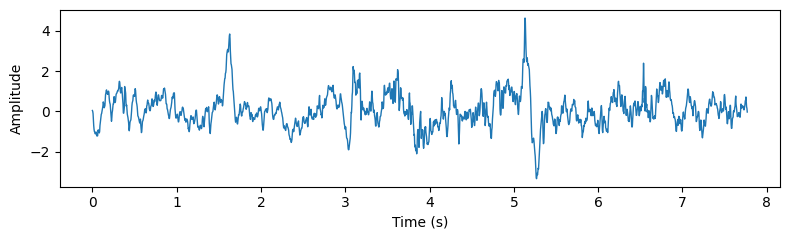

In [9]:
start = 10

duration = 14  # seconds

segment = eeg_data["non_seizure"][1][start:start + duration*fs]

t = np.arange(len(segment)) / fs

plt.figure(figsize=(8, 2.5))

plt.plot(t, segment, linewidth=1)

plt.xlabel("Time (s)")

plt.ylabel("Amplitude")

plt.tight_layout()

plt.show()

In [5]:
import numpy as np

# =========================
# CHAOTIC MAPS
# =========================

def logistic_map(
    n_total=20000,
    n_discard=10000,
    r=4.0,
    x0=None,
    seed=None,
):
    rng = np.random.default_rng(seed)

    if x0 is None:
        x0 = rng.random()

    x = np.empty(n_total, dtype=np.float64)
    x[0] = x0

    for i in range(n_total - 1):
        x[i + 1] = r * x[i] * (1.0 - x[i])
    return x[n_discard:]


def tent_map(
    n_total=20000,
    n_discard=10000,
    mu=1.999,
    x0=0.123456789,
    seed=None,
):
    rng = np.random.default_rng(seed)

    x = np.empty(n_total, dtype=np.float64)
    x[0] = x0

    for i in range(n_total - 1):
        if x[i] < 0.5:
            xn = mu * x[i]
        else:
            xn = mu * (1.0 - x[i])

        # prevent numerical collapse
        xn += 1e-12 * rng.normal()

        # keep in domain
        x[i + 1] = np.clip(xn, 0, 1)

    return x[n_discard:]


def henon_map(
    n_total=20000,
    n_discard=10000,
    a=1.4,
    b=0.3,
    x0=0.1,
    y0=0.3,
    seed=None,
):
    x = np.empty(n_total, dtype=np.float64)
    y = np.empty(n_total, dtype=np.float64)

    x[0], y[0] = x0, y0

    for i in range(n_total - 1):
        x[i + 1] = 1.0 - a * x[i]**2 + y[i]
        y[i + 1] = b * x[i]

    return x[n_discard:]


def lorenz_system(
    n_total=200000,
    n_discard=10000,
    dt=0.02,
    sigma=10.0,
    rho=28.0,
    beta=8/3,
    seed=None,
):

    rng = np.random.default_rng(seed)

    x = np.empty(n_total, dtype=np.float64)
    y = np.empty(n_total, dtype=np.float64)
    z = np.empty(n_total, dtype=np.float64)

    # proper initial condition
    x[0], y[0], z[0] = 1.0, 1.0, 1.0

    def f(x, y, z):
        dx = sigma * (y - x)
        dy = x * (rho - z) - y
        dz = x * y - beta * z
        return dx, dy, dz

    for i in range(n_total - 1):
        x0, y0, z0 = x[i], y[i], z[i]

        k1 = f(x0, y0, z0)
        k2 = f(x0 + dt*k1[0]/2, y0 + dt*k1[1]/2, z0 + dt*k1[2]/2)
        k3 = f(x0 + dt*k2[0]/2, y0 + dt*k2[1]/2, z0 + dt*k2[2]/2)
        k4 = f(x0 + dt*k3[0], y0 + dt*k3[1], z0 + dt*k3[2])

        x[i+1] = x0 + dt/6 * (k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
        y[i+1] = y0 + dt/6 * (k1[1] + 2*k2[1] + 2*k3[1] + k4[1])
        z[i+1] = z0 + dt/6 * (k1[2] + 2*k2[2] + 2*k3[2] + k4[2])
    x=x[::10]
    return x[n_discard:]


# =========================
# STOCHASTIC NOISE
# =========================

def one_over_f_noise(
    k,
    n_total=20000,
    n_discard=10000,
    seed=None,
):
    rng = np.random.default_rng(seed)

    x = rng.normal(0.0, 1.0, size=n_total)

    Xf = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n_total)

    freqs[0] = freqs[1]
    Xf *= freqs ** (-k / 2.0)

    y = np.fft.irfft(Xf, n=n_total)
    y = y[n_discard:]

    y = y / np.std(y)
    return y


# =========================
# DETERMINISTIC BASELINES
# =========================

def sine_wave(
    n_total=20000,
    n_discard=10000,
    freq=5.0,
    seed=None,
):
    t = np.linspace(0, 10, n_total)
    x = np.sin(2 * np.pi * freq * t)
    return x[n_discard:]


def quasi_periodic(
    n_total=20000,
    n_discard=10000,
    f1=3.0,
    f2=7.1,
    seed=None,
):
    t = np.linspace(0, 10, n_total)
    x = np.sin(2*np.pi*f1*t) + np.sin(2*np.pi*f2*t)
    return x[n_discard:]


# =========================
# NOISE ADDITION
# =========================

def add_noise(signal, sigma, seed=None):
    if sigma == 0:
        return signal.copy()

    rng = np.random.default_rng(seed)
    noise_std = sigma * np.std(signal)
    noise = rng.normal(0.0, noise_std, size=signal.shape)

    return signal + noise


# =========================
# ENSEMBLE GENERATORS
# =========================

def generate_chaos_ensemble(
    generator_func,
    sigmas,
    n_realizations=10,
):
    data = {}

    for sigma in sigmas:
        realizations = []
        for _ in range(n_realizations):
            clean = generator_func()
            noisy = add_noise(clean, sigma)
            realizations.append(noisy)
        data[sigma] = realizations

    return data


def generate_logistic_ensemble(sigmas, n_realizations=10):
    return generate_chaos_ensemble(logistic_map, sigmas, n_realizations)


def generate_tent_ensemble(sigmas, n_realizations=10):
    return generate_chaos_ensemble(tent_map, sigmas, n_realizations)


def generate_henon_ensemble(sigmas, n_realizations=10):
    return generate_chaos_ensemble(henon_map, sigmas, n_realizations)


def generate_lorenz_ensemble(sigmas, n_realizations=10):
    return generate_chaos_ensemble(lorenz_system, sigmas, n_realizations)


def generate_k_noise_ensemble(
    ks,
    n_realizations=100,
):
    data = {}

    for k in ks:
        realizations = []
        for _ in range(n_realizations):
            y = one_over_f_noise(k)
            realizations.append(y)
        data[k] = realizations

    return data


def generate_sine_ensemble(n_realizations=10):
    return [sine_wave() for _ in range(n_realizations)]


def generate_quasi_periodic_ensemble(n_realizations=10):
    return [quasi_periodic() for _ in range(n_realizations)]

In [6]:
def ordinal_patterns(x, D=3, tau=1):
    n = len(x)
    patterns = []

    for i in range(n - (D - 1) * tau):
        window = x[i : i + D * tau : tau]
        pattern = tuple(np.argsort(window))
        patterns.append(pattern)

    return patterns

from collections import Counter
import itertools

def pattern_counts(patterns, D):

    all_patterns = list(itertools.permutations(range(D)))
    counts = Counter(patterns)

    # ensure missing patterns appear with count 0
    return {p: counts.get(p, 0) for p in all_patterns}

def pattern_probabilities(counts):
    total = sum(counts.values())
    return {p: c / total for p, c in counts.items()}

def ordered_patterns(D):
    return list(itertools.permutations(range(D)))

def plot_pattern_distribution(probs, D, title=None):
    patterns = ordered_patterns(D)
    print(patterns)
    values = [probs[p] for p in patterns]
    plt.figure(figsize=(12, 4))
    plt.bar(range(len(values)), values, width=1.0)
    plt.xlabel("Ordinal pattern index")
    plt.ylabel("Probability")
    plt.title(title if title else f"Ordinal pattern distribution (D={D})")
    plt.tight_layout()
    plt.show()

In [7]:
import numpy as np

# =========================
# CORE: ENTROPY + COMPLEXITY
# =========================

def jensen_shannon_complexity(probs, D):
    p = np.array(list(probs.values()), dtype=np.float64)
    p = p / p.sum()

    N = len(p)
    uniform = np.ones(N) / N

    def H(x):
        x = x[x > 0]
        return -np.sum(x * np.log(x))

    # Jensen-Shannon divergence
    M = 0.5 * (p + uniform)
    JS = H(M) - 0.5 * H(p) - 0.5 * H(uniform)

    JS_max = -0.5 * ((N+1)/N * np.log(N+1) - 2*np.log(2*N) + np.log(N))
    Q0 = 1 / JS_max

    H_norm = H(p) / np.log(N)
    C = Q0 * JS * H_norm

    return H_norm, C


# =========================
# EXTROPY
# =========================

def normalized_extropy(probs):
    p = np.array(list(probs.values()), dtype=np.float64)
    p = p / p.sum()

    # numerical safety
    p = np.clip(p, 1e-10, 1 - 1e-10)

    def J(x):
        return -np.sum((1 - x) * np.log(1 - x))

    N = len(p)
    uniform = np.ones(N) / N

    J_p = J(p)
    J_max = J(uniform)

    return J_p / J_max


# =========================
# SINGLE PASS COMPUTATION
# =========================

def compute_all_measures(x, D=5):
    patterns = ordinal_patterns(x, D=D)
    counts = pattern_counts(patterns, D=D)
    probs = pattern_probabilities(counts)

    # compute everything from SAME distribution
    H, C = jensen_shannon_complexity(probs, D)
    J = normalized_extropy(probs)

    return H, J, C


# =========================
# AGGREGATION
# =========================

def aggregate_measures(realizations, D=5):
    Hs, Js, Cs = [], [], []

    for x in realizations:
        H, J, C = compute_all_measures(x, D)
        Hs.append(H)
        Js.append(J)
        Cs.append(C)

    return (
        np.mean(Hs),
        np.mean(Js),
        np.mean(Cs),
    )

In [8]:
sigmas = np.linspace(0, 1, 50)   
ks = np.linspace(0, 3, 30)       # for 1/f^k noise

In [9]:
# =========================
# CHAOS (ALL MAPS)
# =========================

chaos_generators = {
    "logistic": logistic_map,
    "tent": tent_map,
    "henon": henon_map,
    "lorenz": lorenz_system,
}

H_chaos = {}
J_chaos = {}
C_chaos = {}

print("Entropy + Extropy (Chaos)")

for name, gen_func in chaos_generators.items():

    H_list, J_list, C_list = [], [], []

    for sigma in sigmas:
        realizations = generate_chaos_ensemble(
            gen_func,
            sigmas=[sigma]
        )[sigma]

        H, J, C = aggregate_measures(realizations, D=5)

        H_list.append(H)
        J_list.append(J)
        C_list.append(C)

        print(f"{name} sigma: {int(100*sigma)}%", end="\r")

    H_chaos[name] = np.array(H_list)
    J_chaos[name] = np.array(J_list)
    C_chaos[name] = np.array(C_list)

    print()  # newline after each system


# =========================
# NOISE (k-spectrum)
# =========================

H_k, J_k, C_k = [], [], []

print("\nNoise")

for k in ks:
    realizations = generate_k_noise_ensemble(ks=[k])[k]

    H, J, C = aggregate_measures(realizations, D=5)

    H_k.append(H)
    J_k.append(J)
    C_k.append(C)

    print("k:", int(100*k/3), "%", end="\r")

H_k = np.array(H_k)
J_k = np.array(J_k)
C_k = np.array(C_k)


# =========================
# OPTIONAL: DETERMINISTIC BASELINES
# =========================

print("\nDeterministic (Sine / Quasi)")

H_sine, J_sine, C_sine = aggregate_measures(
    generate_sine_ensemble(),
    D=5
)

H_quasi, J_quasi, C_quasi = aggregate_measures(
    generate_quasi_periodic_ensemble(),
    D=5
)


Entropy + Extropy (Chaos)
logistic sigma: 100%
tent sigma: 100%
henon sigma: 100%
lorenz sigma: 100%

Noise
k: 100 %
Deterministic (Sine / Quasi)


In [10]:
def compute_points(realizations, D=5):
    Hs, Js, Cs = [], [], []

    for x in realizations:
        H, J, C = compute_all_measures(x, D)
        Hs.append(H)
        Js.append(J)
        Cs.append(C)

    return np.array(Hs), np.array(Js), np.array(Cs)


H_ns, J_ns, C_ns = compute_points(eeg_data["non_seizure"])
H_sz, J_sz, C_sz = compute_points(eeg_data["seizure"])

H_ns_2, J_ns_2, C_ns_2 = compute_points(eeg_data_2["non_seizure"])
H_sz_2, J_sz_2, C_sz_2 = compute_points(eeg_data_2["seizure"])


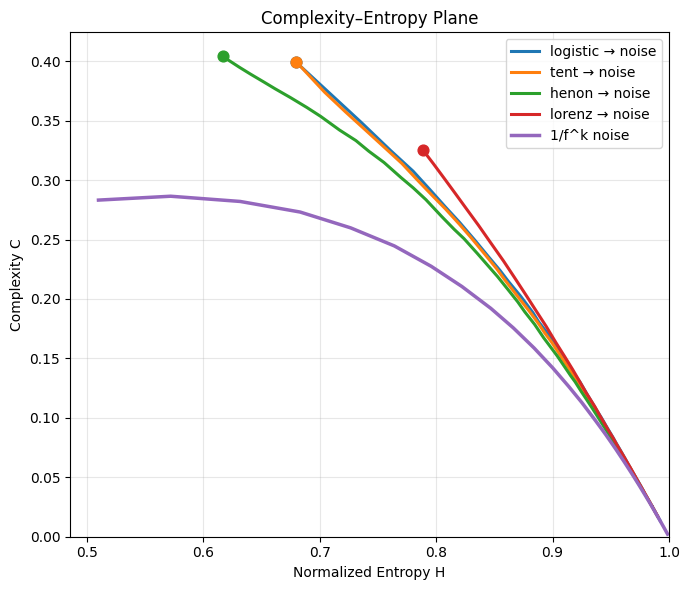

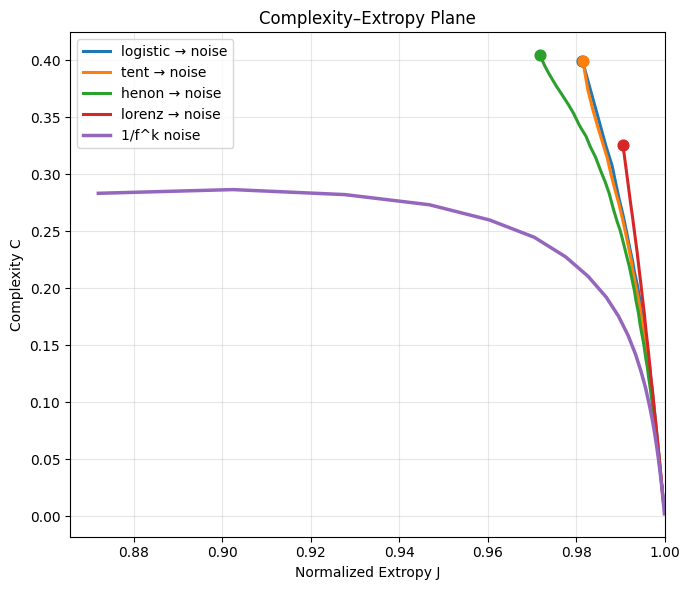

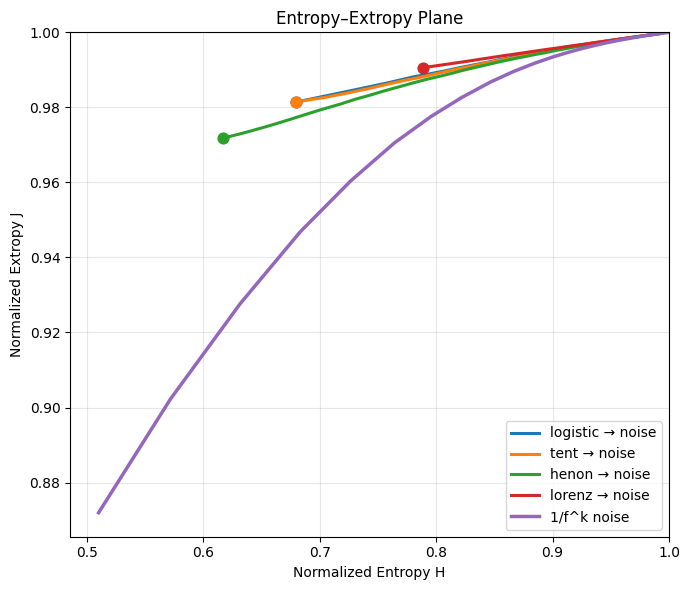

In [11]:

# =========================
# COMPLEXITY–ENTROPY
# =========================

plt.figure(figsize=(7,6))

for name in H_chaos:

    line, = plt.plot(
        H_chaos[name],
        C_chaos[name],
        linewidth=2.2,
        label=f"{name} → noise"
    )

    color = line.get_color()

    # start marker (sigma = 0)
    plt.scatter(
        H_chaos[name][0],
        C_chaos[name][0],
        s=60,
        color=color,
        zorder=3
    )

# k-noise
plt.plot(H_k, C_k, linewidth=2.5, label="1/f^k noise")

plt.xlabel("Normalized Entropy H")
plt.ylabel("Complexity C")
plt.title("Complexity–Entropy Plane")

plt.xlim(None, 1)
plt.ylim(0, None)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# =========================
# COMPLEXITY–EXTROPY
# =========================

plt.figure(figsize=(7,6))

for name in J_chaos:

    line, = plt.plot(
        J_chaos[name],
        C_chaos[name],
        linewidth=2.2,
        label=f"{name} → noise"
    )

    color = line.get_color()

    plt.scatter(
        J_chaos[name][0],
        C_chaos[name][0],
        s=60,
        color=color,
        zorder=3
    )

# k-noise
plt.plot(J_k, C_k, linewidth=2.5, label="1/f^k noise")

plt.xlabel("Normalized Extropy J")
plt.ylabel("Complexity C")
plt.title("Complexity–Extropy Plane")

plt.xlim(None, 1)
plt.ylim(None, None)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# =========================
# ENTROPY–EXTROPY
# =========================

plt.figure(figsize=(7,6))

for name in H_chaos:

    line, = plt.plot(
        H_chaos[name],
        J_chaos[name],
        linewidth=2.2,
        label=f"{name} → noise"
    )

    color = line.get_color()

    plt.scatter(
        H_chaos[name][0],
        J_chaos[name][0],
        s=60,
        color=color,
        zorder=3
    )

# k-noise
plt.plot(H_k, J_k, linewidth=2.5, label="1/f^k noise")

plt.xlabel("Normalized Entropy H")
plt.ylabel("Normalized Extropy J")
plt.title("Entropy–Extropy Plane")

plt.xlim(None, 1)
plt.ylim(None, 1)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

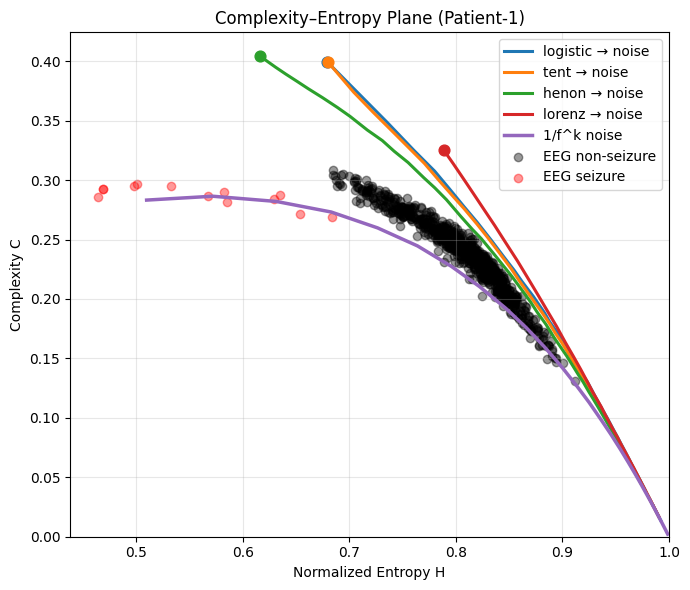

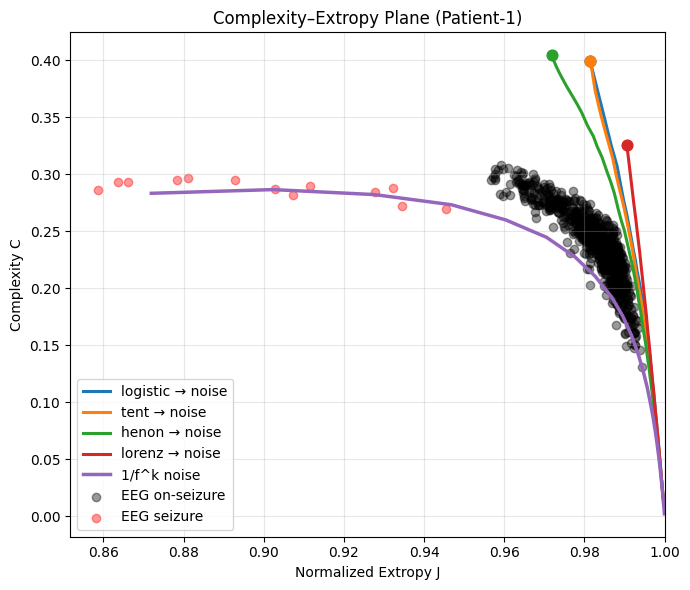

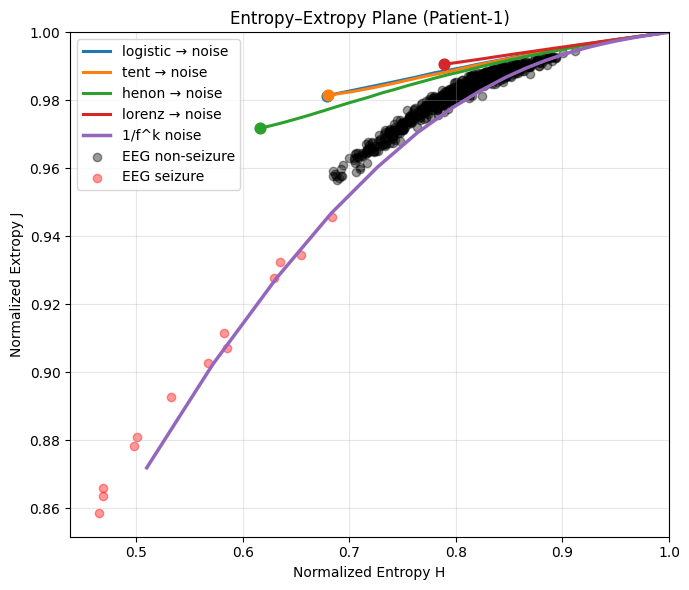

In [12]:

# =========================
# COMPLEXITY–ENTROPY
# =========================

plt.figure(figsize=(7,6))

for name in H_chaos:

    line, = plt.plot(
        H_chaos[name],
        C_chaos[name],
        linewidth=2.2,
        label=f"{name} → noise"
    )

    color = line.get_color()

    # start marker (sigma = 0)
    plt.scatter(
        H_chaos[name][0],
        C_chaos[name][0],
        s=60,
        color=color,
        zorder=3
    )

# k-noise
plt.plot(H_k, C_k, linewidth=2.5, label="1/f^k noise")

plt.scatter(H_ns, C_ns, color="black", alpha=0.4, label="EEG non-seizure")
plt.scatter(H_sz, C_sz, color="red", alpha=0.4, label="EEG seizure")
plt.xlabel("Normalized Entropy H")
plt.ylabel("Complexity C")
plt.title("Complexity–Entropy Plane (Patient-1)")

plt.xlim(None, 1)
plt.ylim(0, None)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# =========================
# COMPLEXITY–EXTROPY
# =========================

plt.figure(figsize=(7,6))

for name in J_chaos:

    line, = plt.plot(
        J_chaos[name],
        C_chaos[name],
        linewidth=2.2,
        label=f"{name} → noise"
    )

    color = line.get_color()

    plt.scatter(
        J_chaos[name][0],
        C_chaos[name][0],
        s=60,
        color=color,
        zorder=3
    )

# k-noise
plt.plot(J_k, C_k, linewidth=2.5, label="1/f^k noise")
plt.scatter(J_ns, C_ns, color="black", alpha=0.4, label="EEG on-seizure")
plt.scatter(J_sz, C_sz, color="red", alpha=0.4, label="EEG seizure")
plt.xlabel("Normalized Extropy J")
plt.ylabel("Complexity C")
plt.title("Complexity–Extropy Plane (Patient-1)")

plt.xlim(None, 1)
plt.ylim(None, None)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# =========================
# ENTROPY–EXTROPY
# =========================

plt.figure(figsize=(7,6))

for name in H_chaos:

    line, = plt.plot(
        H_chaos[name],
        J_chaos[name],
        linewidth=2.2,
        label=f"{name} → noise"
    )

    color = line.get_color()

    plt.scatter(
        H_chaos[name][0],
        J_chaos[name][0],
        s=60,
        color=color,
        zorder=3
    )

# k-noise
plt.plot(H_k, J_k, linewidth=2.5, label="1/f^k noise")
plt.scatter(H_ns, J_ns, color="black", alpha=0.4, label="EEG non-seizure")
plt.scatter(H_sz, J_sz, color="red", alpha=0.4, label="EEG seizure")
plt.xlabel("Normalized Entropy H")
plt.ylabel("Normalized Extropy J")
plt.title("Entropy–Extropy Plane (Patient-1)")

plt.xlim(None, 1)
plt.ylim(None, 1)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

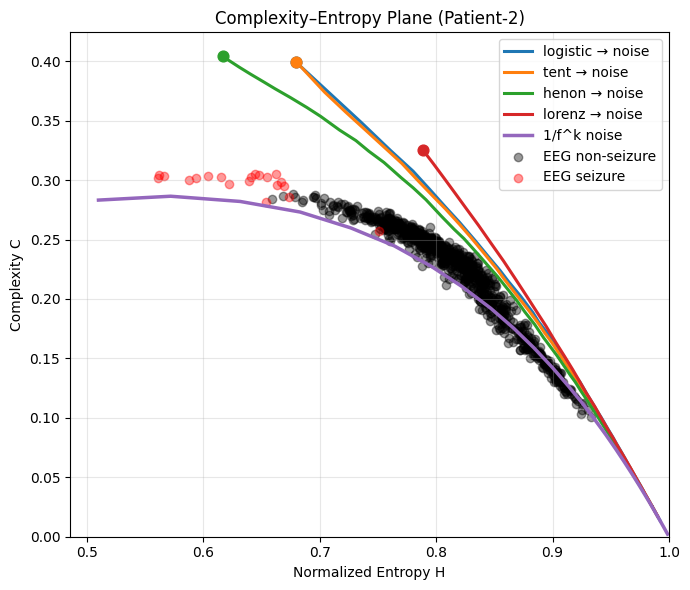

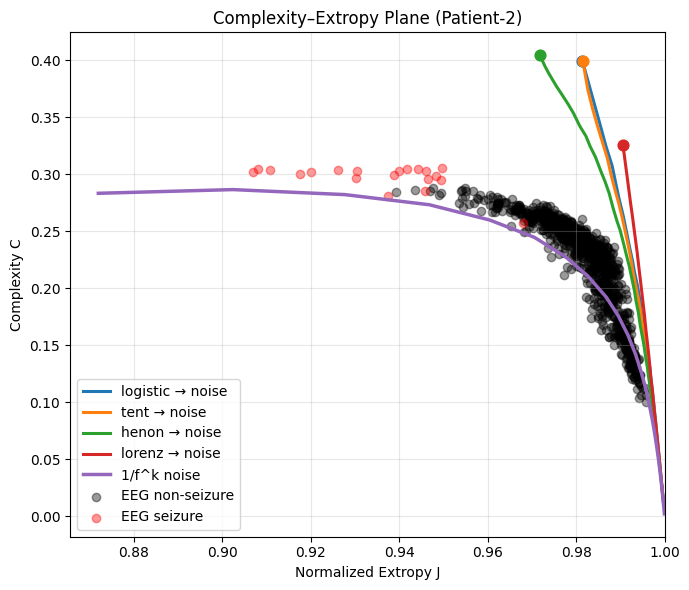

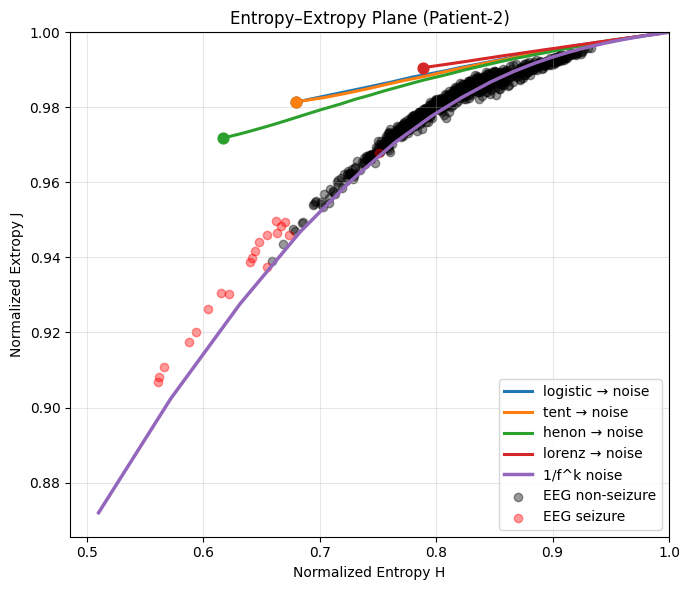

In [13]:

# =========================
# COMPLEXITY–ENTROPY
# =========================

plt.figure(figsize=(7,6))

for name in H_chaos:

    line, = plt.plot(
        H_chaos[name],
        C_chaos[name],
        linewidth=2.2,
        label=f"{name} → noise"
    )

    color = line.get_color()

    # start marker (sigma = 0)
    plt.scatter(
        H_chaos[name][0],
        C_chaos[name][0],
        s=60,
        color=color,
        zorder=3
    )

# k-noise
plt.plot(H_k, C_k, linewidth=2.5, label="1/f^k noise")
plt.scatter(H_ns_2, C_ns_2, color="black", alpha=0.4, label="EEG non-seizure")
plt.scatter(H_sz_2, C_sz_2, color="red", alpha=0.4, label="EEG seizure")
plt.xlabel("Normalized Entropy H")
plt.ylabel("Complexity C")
plt.title("Complexity–Entropy Plane (Patient-2)")

plt.xlim(None, 1)
plt.ylim(0, None)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# =========================
# COMPLEXITY–EXTROPY
# =========================

plt.figure(figsize=(7,6))

for name in J_chaos:

    line, = plt.plot(
        J_chaos[name],
        C_chaos[name],
        linewidth=2.2,
        label=f"{name} → noise"
    )

    color = line.get_color()

    plt.scatter(
        J_chaos[name][0],
        C_chaos[name][0],
        s=60,
        color=color,
        zorder=3
    )

# k-noise
plt.plot(J_k, C_k, linewidth=2.5, label="1/f^k noise")
plt.scatter(J_ns_2, C_ns_2, color="black", alpha=0.4, label="EEG non-seizure")
plt.scatter(J_sz_2, C_sz_2, color="red", alpha=0.4, label="EEG seizure")
plt.xlabel("Normalized Extropy J")
plt.ylabel("Complexity C")
plt.title("Complexity–Extropy Plane (Patient-2)")

plt.xlim(None, 1)
plt.ylim(None, None)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# =========================
# ENTROPY–EXTROPY
# =========================

plt.figure(figsize=(7,6))

for name in H_chaos:

    line, = plt.plot(
        H_chaos[name],
        J_chaos[name],
        linewidth=2.2,
        label=f"{name} → noise"
    )

    color = line.get_color()

    plt.scatter(
        H_chaos[name][0],
        J_chaos[name][0],
        s=60,
        color=color,
        zorder=3
    )

# k-noise
plt.plot(H_k, J_k, linewidth=2.5, label="1/f^k noise")
plt.scatter(H_ns_2, J_ns_2, color="black", alpha=0.4, label="EEG non-seizure")
plt.scatter(H_sz_2, J_sz_2, color="red", alpha=0.4, label="EEG seizure")
plt.xlabel("Normalized Entropy H")
plt.ylabel("Normalized Extropy J")
plt.title("Entropy–Extropy Plane (Patient-2)")

plt.xlim(None, 1)
plt.ylim(None, 1)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()